In [3]:
import pandas as pd

df = pd.read_csv("../data/hrrp_readmissions.csv")


In [4]:
df.head()

,Facility Name,Facility ID,State,Measure Name,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date
0,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-AMI-HRRP,296.0,NaN,0.9483,13.0146,13.7235,36,7/1/2020,6/30/2023
1,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-CABG-HRRP,151.0,NaN,0.9509,9.6899,10.1898,13,7/1/2020,6/30/2023
2,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-HF-HRRP,681.0,NaN,1.0597,21.5645,20.3495,151,7/1/2020,6/30/2023
3,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-HIP-KNEE-HRRP,NaN,NaN,0.9654,4.2680,4.4211,Too Few to Report,7/1/2020,6/30/2023
4,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-PN-HRRP,490.0,NaN,0.9715,16.1137,16.5863,77,7/1/2020,6/30/2023


In [5]:
df.shape

(18510, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18510 entries, 0 to 18509
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Facility Name               18510 non-null  object 
 1   Facility ID                 18510 non-null  int64  
 2   State                       18510 non-null  object 
 3   Measure Name                18510 non-null  object 
 4   Number of Discharges        8340 non-null   float64
 5   Footnote                    6583 non-null   float64
 6   Excess Readmission Ratio    11927 non-null  float64
 7   Predicted Readmission Rate  11927 non-null  float64
 8   Expected Readmission Rate   11927 non-null  float64
 9   Number of Readmissions      11927 non-null  object 
 10  Start Date                  18510 non-null  object 
 11  End Date                    18510 non-null  object 
dtypes: float64(5), int64(1), object(6)
memory usage: 1.7+ MB


In [7]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

df.head().T

,0,1,2,3,4
Facility Name,SOUTHEAST HEALTH MEDICAL CENTER,SOUTHEAST HEALTH MEDICAL CENTER,SOUTHEAST HEALTH MEDICAL CENTER,SOUTHEAST HEALTH MEDICAL CENTER,SOUTHEAST HEALTH MEDICAL CENTER
Facility ID,10001,10001,10001,10001,10001
State,AL,AL,AL,AL,AL
Measure Name,READM-30-AMI-HRRP,READM-30-CABG-HRRP,READM-30-HF-HRRP,READM-30-HIP-KNEE-HRRP,READM-30-PN-HRRP
Number of Discharges,296.0,151.0,681.0,NaN,490.0
Footnote,NaN,NaN,NaN,NaN,NaN
Excess Readmission Ratio,0.9483,0.9509,1.0597,0.9654,0.9715
Predicted Readmission Rate,13.0146,9.6899,21.5645,4.268,16.1137
Expected Readmission Rate,13.7235,10.1898,20.3495,4.4211,16.5863
Number of Readmissions,36,13,151,Too Few to Report,77


In [8]:
df.columns.tolist()

['Facility Name',
 'Facility ID',
 'State',
 'Measure Name',
 'Number of Discharges',
 'Footnote',
 'Excess Readmission Ratio',
 'Predicted Readmission Rate',
 'Expected Readmission Rate',
 'Number of Readmissions',
 'Start Date',
 'End Date']

In [9]:
df = df.rename(columns={
    'Facility Name': 'facility_name',
    'Facility ID': 'facility_id',
    'State': 'state',
    'Measure Name': 'measure',
    'Number of Discharges': 'num_discharges',
    'Footnote': 'footnote',
    'Excess Readmission Ratio': 'excess_readmission_ratio',
    'Predicted Readmission Rate': 'predicted_readmission_rate',
    'Expected Readmission Rate': 'expected_readmission_rate',
    'Number of Readmissions': 'num_readmissions',
    'Start Date': 'start_date',
    'End Date': 'end_date'
})


In [10]:
df['footnote'].value_counts(dropna=False)


footnote
NaN    11927
5.0     3272
1.0     3092
7.0      219
Name: count, dtype: int64

In [11]:
df.isna().sum()

facility_name                     0
facility_id                       0
state                             0
measure                           0
num_discharges                10170
footnote                      11927
excess_readmission_ratio       6583
predicted_readmission_rate     6583
expected_readmission_rate      6583
num_readmissions               6583
start_date                        0
end_date                          0
dtype: int64

In [12]:
numeric_cols = [
    'num_discharges',
    'excess_readmission_ratio',
    'predicted_readmission_rate',
    'expected_readmission_rate',
    'num_readmissions'
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')


In [13]:
df[numeric_cols].describe()

,num_discharges,excess_readmission_ratio,predicted_readmission_rate,expected_readmission_rate,num_readmissions
count,8340.000000,11927.000000,11927.000000,11927.000000,8121.000000
mean,279.269904,1.001719,14.995386,14.961234,48.074868
std,266.018069,0.080547,5.017854,4.871997,48.488707
min,0.000000,0.477900,1.674200,2.892100,11.000000
25%,115.000000,0.956550,12.533000,12.612800,19.000000
50%,197.000000,0.998200,16.060200,16.146000,31.000000
75%,354.000000,1.043000,18.609000,18.667350,59.000000
max,4501.000000,1.643000,27.809500,25.394200,877.000000


In [14]:
df_clean = df.dropna(subset=['excess_readmission_ratio'])

In [15]:
df_clean.groupby('measure')['excess_readmission_ratio'].describe()


,count,mean,std,min,25%,50%,75%,max
measure,,,,,,,,
READM-30-AMI-HRRP,1763.0,1.001909,0.071290,0.7224,0.957750,0.9997,1.044150,1.2809
READM-30-CABG-HRRP,883.0,1.000725,0.080237,0.7443,0.947950,0.9989,1.048400,1.3451
READM-30-COPD-HRRP,2324.0,1.001683,0.053735,0.8087,0.966300,0.9969,1.033725,1.2768
READM-30-HF-HRRP,2638.0,1.001213,0.066730,0.7390,0.959125,1.0009,1.042375,1.3070
READM-30-HIP-KNEE-HRRP,1588.0,1.003763,0.143955,0.4779,0.910800,0.9912,1.091500,1.6430
READM-30-PN-HRRP,2731.0,1.001250,0.064605,0.7803,0.960400,0.9972,1.038000,1.4919


In [16]:
import matplotlib.pyplot as plt

In [17]:
numeric_cols = [
    'num_discharges',
    'excess_readmission_ratio',
    'predicted_readmission_rate',
    'expected_readmission_rate',
    'num_readmissions'
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

df_clean = df.dropna(subset=['excess_readmission_ratio'])

df_clean = df_clean[df_clean['num_discharges'] > 0]

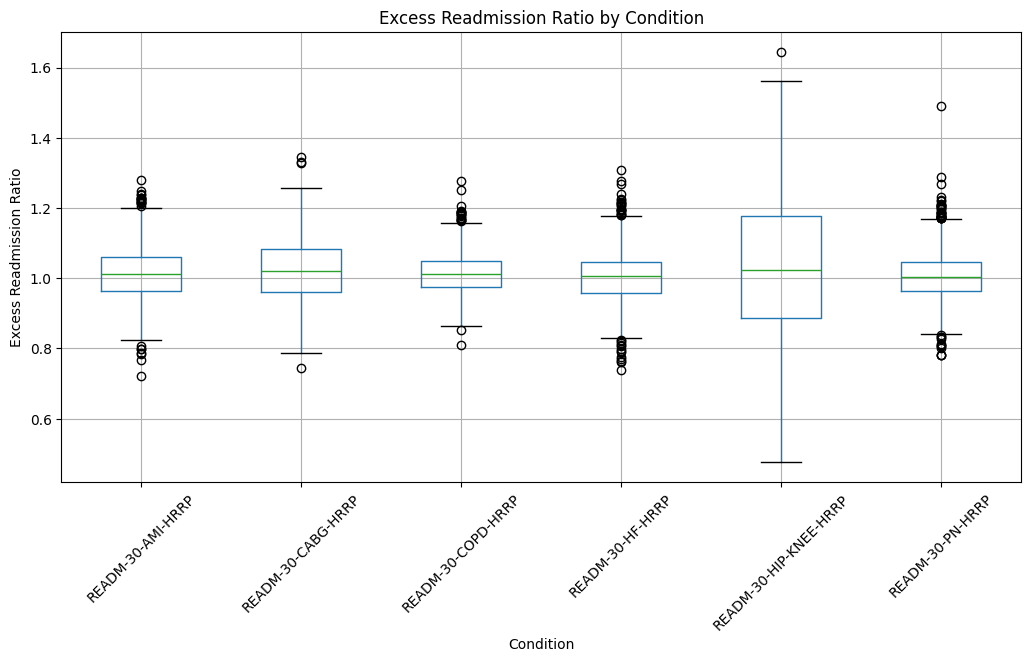

In [18]:
df_clean.boxplot(
    column='excess_readmission_ratio',
    by='measure',
    figsize=(12,6),
    rot=45
)

plt.title('Excess Readmission Ratio by Condition')
plt.suptitle('')
plt.xlabel('Condition')
plt.ylabel('Excess Readmission Ratio')
plt.show()


In [19]:
df_clean.groupby('measure')['excess_readmission_ratio'].mean()


measure
READM-30-AMI-HRRP         1.011517
READM-30-CABG-HRRP        1.023342
READM-30-COPD-HRRP        1.013809
READM-30-HF-HRRP          1.003666
READM-30-HIP-KNEE-HRRP    1.025942
READM-30-PN-HRRP          1.006083
Name: excess_readmission_ratio, dtype: float64

In [21]:
df_clean.groupby('measure')['excess_readmission_ratio'].median()

measure
READM-30-AMI-HRRP         1.01155
READM-30-CABG-HRRP        1.02000
READM-30-COPD-HRRP        1.01190
READM-30-HF-HRRP          1.00500
READM-30-HIP-KNEE-HRRP    1.02420
READM-30-PN-HRRP          1.00360
Name: excess_readmission_ratio, dtype: float64